# Notebook 3 — Keras Utility-Based Pipeline

In [1]:
print("python")

python


In [2]:
%load_ext autotime
import tensorflow as tf
print("TF Version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

TF Version: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
time: 8.91 s (started: 2026-04-02 22:11:03 +05:30)


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import time
import shutil

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import accuracy_score

time: 94 ms (started: 2026-04-02 22:11:12 +05:30)


In [4]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

time: 16 ms (started: 2026-04-02 22:11:12 +05:30)


* Load data: `image_dataset_from_directory`
  * auto labels + 80/20 split
  * resize (64×64), batch = 8
* Inspect: class names + visualize batch
* Augment: `RandomFlip` + `RandomRotation` via `.map()`
* Optimize: `.cache().prefetch(AUTOTUNE)`

In [5]:
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 8

time: 0 ns (started: 2026-04-02 22:11:12 +05:30)


In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    RAW_DIR,
    labels='inferred',          
    label_mode='int',           
    validation_split=0.2,       
    subset='training',          
    seed=1337,                  # Shuffle seed for reproducible splits
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6000 files belonging to 2 classes.
Using 4800 files for training.
time: 610 ms (started: 2026-04-02 22:11:12 +05:30)


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    RAW_DIR,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6000 files belonging to 2 classes.
Using 1200 files for validation.
time: 500 ms (started: 2026-04-02 22:11:13 +05:30)


Class names inferred by Keras: ['class_0_non_agri', 'class_1_agri']


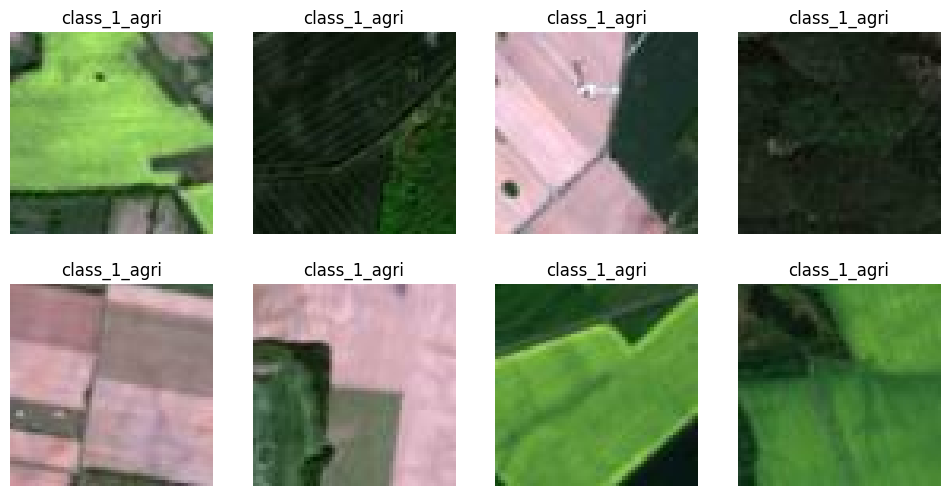

time: 610 ms (started: 2026-04-02 22:11:13 +05:30)


In [8]:
print(f"Class names inferred by Keras: {train_ds.class_names}")

plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1): 
    for i in range(BATCH_SIZE):
        ax = plt.subplot(2, 4, i + 1)
        # Images are loaded as float32, so we convert to uint8 for display
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

# Apply augmentation to the training dataset using map
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Configure for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset is now configured for high performance!")

Dataset is now configured for high performance!
time: 188 ms (started: 2026-04-02 22:11:14 +05:30)


In [10]:
gpu_list = tf.config.list_physical_devices('GPU')

device = "gpu" if gpu_list !=[] else "cpu"
print(f"Device available for training: {device}")

Device available for training: cpu
time: 0 ns (started: 2026-04-02 22:11:14 +05:30)


In [11]:
# Set seed for reproducibility
seed_value = 7331
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

time: 0 ns (started: 2026-04-02 22:11:14 +05:30)


In [12]:
(RAW_DIR, dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT',
 '..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

time: 0 ns (started: 2026-04-02 22:11:14 +05:30)


In [13]:
fnames = []
for dirname, _, filenames in os.walk(RAW_DIR):
    for filename in filenames:
        fnames.append(os.path.join(dirname, filename))
print(f"total files in dataset: {len(fnames)}")
nfname_print=2
for f in fnames[:nfname_print]:
    print(f)
for f in fnames[-nfname_print:]:
    print(f)

total files in dataset: 6000
..\data\raw\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg
..\data\raw\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg
..\data\raw\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQD_20250427T170513.SAFE_0805.jpg
..\data\raw\images_dataSAT\class_1_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQD_20250427T170513.SAFE_0812.jpg
time: 63 ms (started: 2026-04-02 22:11:14 +05:30)


In [14]:
img_w, img_h = 64, 64
n_channels = 3
batch_size = 128
lr = 0.001 
n_epochs = 5

steps_per_epoch = None
validation_steps = None 

model_name = "best_model.keras.h5"

time: 0 ns (started: 2026-04-02 22:11:14 +05:30)


In [15]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40, 
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

time: 0 ns (started: 2026-04-02 22:11:14 +05:30)


In [16]:
train_generator = datagen.flow_from_directory(
    RAW_DIR,
    target_size = (img_w, img_h),
    batch_size= batch_size,
    class_mode="binary",
    subset="training"
 )

Found 4800 images belonging to 2 classes.
time: 422 ms (started: 2026-04-02 22:11:14 +05:30)


In [17]:
validation_generator = datagen.flow_from_directory(
    RAW_DIR,
    target_size =(img_w, img_h),
    batch_size = batch_size, 
    class_mode="binary",
    subset="validation"
)

Found 1200 images belonging to 2 classes.
time: 125 ms (started: 2026-04-02 22:11:15 +05:30)


In [19]:
model = Sequential([
 Conv2D(32 , (5,5) , activation="relu",padding="same",strides=(1,1), kernel_initializer=HeUniform(), input_shape=(img_w, img_h, n_channels)),
 MaxPooling2D(2,2),
 BatchNormalization(),

 Conv2D(64, (5,5) , activation="relu",padding="same" , strides=(1,1), kernel_initializer=HeUniform()),
 MaxPooling2D(2,2),
 BatchNormalization(),

 Conv2D(128, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
 MaxPooling2D(2,2),
 BatchNormalization(),
 
 Conv2D(256, (5,5) , activation="relu",padding="same" ,strides=(1,1), kernel_initializer=HeUniform()),
 MaxPooling2D(2,2),
 BatchNormalization(),
 
 GlobalAveragePooling2D(),

 Dense(64,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

 Dense(128,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

 Dense(256,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

 Dense(512,activation="relu" , kernel_initializer=HeUniform()),
 BatchNormalization(),
 Dropout(0.4),

 Dense(1 , activation="sigmoid")
 
 ])

loss = "binary_crossentropy"
model.compile(optimizer=Adam(learning_rate=lr),loss=loss, metrics=["accuracy"])

C:\Users\upman\miniconda3\envs\ai-cpu\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


time: 281 ms (started: 2026-04-02 22:11:29 +05:30)


In [20]:
loss = "binary_crossentropy"
model.compile(optimizer=Adam(learning_rate=lr),
              loss=loss, 
              metrics=["accuracy"])

time: 15 ms (started: 2026-04-02 22:11:29 +05:30)


In [21]:
print(f"Training Hyperparameters:\n\
        n_classes (train) = {train_generator.num_classes},\n\
        n_classes (validation) = {validation_generator.num_classes},\n\
        img_w, img_h ={img_w, img_h},\n\
        n_channels = {n_channels},\n\
        batch_size = {batch_size},\n\
        steps_per_epoch = {steps_per_epoch},\n\
        n_epochs = {n_epochs},\n\
        validation_steps = {validation_steps},\n\
        learning_rate = {lr}")

Training Hyperparameters:
        n_classes (train) = 2,
        n_classes (validation) = 2,
        img_w, img_h =(64, 64),
        n_channels = 3,
        batch_size = 128,
        steps_per_epoch = None,
        n_epochs = 5,
        validation_steps = None,
        learning_rate = 0.001
time: 0 ns (started: 2026-04-02 22:11:30 +05:30)


In [22]:
checkpoint_cb = ModelCheckpoint(
    filepath=model_name,
    monitor='val_accuracy',      
    mode='max',              
    save_best_only=True,
    verbose=1
)

time: 0 ns (started: 2026-04-02 22:11:31 +05:30)


In [23]:
print(f"Training on : ==={device}=== with batch size: {batch_size} & lr: {lr}")

fit = model.fit(
    train_generator, 
    epochs= n_epochs,
    steps_per_epoch = steps_per_epoch,
    validation_data=(validation_generator),
    validation_steps = validation_steps,
    callbacks=[checkpoint_cb],
    verbose=1
)

Training on : ===cpu=== with batch size: 128 & lr: 0.001
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8112 - loss: 0.3947
Epoch 1: val_accuracy improved from None to 0.51750, saving model to best_model.keras.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 564ms/step - accuracy: 0.9056 - loss: 0.2165 - val_accuracy: 0.5175 - val_loss: 6.2319
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9763 - loss: 0.0677
Epoch 2: val_accuracy did not improve from 0.51750
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 540ms/step - accuracy: 0.9802 - loss: 0.0587 - val_accuracy: 0.4917 - val_loss: 3.1190
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9759 - loss: 0.0769
Epoch 3: val_accuracy improved from 0.51750 to 0.69000, saving model to best_model.keras.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 541ms/step - accuracy: 0.9773 - loss: 0.0721 - val_accuracy: 0.6900 - val_loss: 1.1150
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9817 - loss: 0.0530
Epoch 4: val_accuracy improved from 0.69000 to 0.79750, saving model to best_model.keras.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 559ms/step - accuracy: 0.9812 - loss: 0.0572 - val_accuracy: 0.7975 - val_loss: 0.8248
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9806 - loss: 0.0489
Epoch 5: val_accuracy did not improve from 0.79750
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 570ms/step - accuracy: 0.9842 - loss: 0.0433 - val_accuracy: 0.7858 - val_loss: 0.6501
time: 1min 53s (started: 2026-04-02 22:11:31 +05:30)


In [24]:
steps = int(np.ceil(validation_generator.samples / validation_generator.batch_size))
batch_size = int(validation_generator.batch_size)

all_preds = []
all_labels = []
for step in range(steps):
    images, labels = next(validation_generator)
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten() 
    all_preds.extend(preds)
    all_labels.extend(labels)
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy Score: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
Accuracy Score: 0.7875
time: 5.91 s (started: 2026-04-02 22:13:24 +05:30)


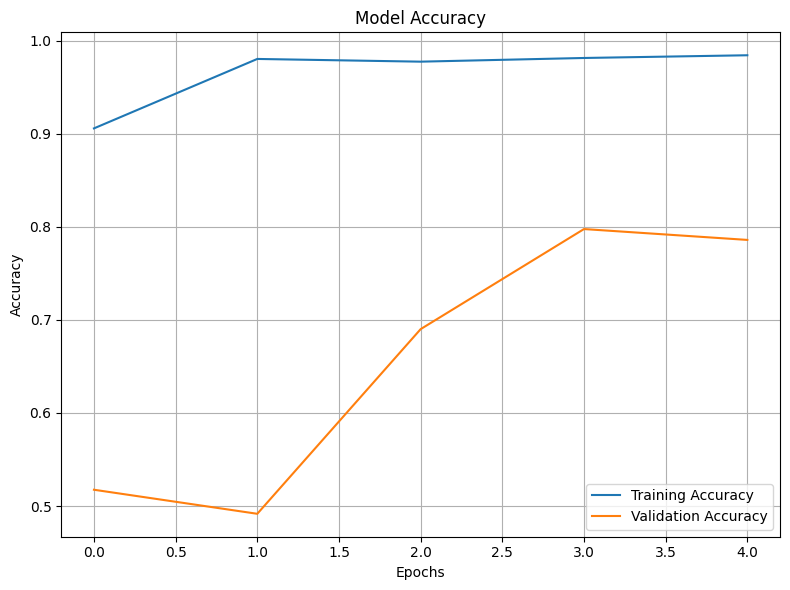

time: 265 ms (started: 2026-04-02 22:13:30 +05:30)


In [25]:
fig, axs = plt.subplots(figsize=(8, 6))

axs.plot(fit.history['accuracy'], label='Training Accuracy')
axs.plot(fit.history['val_accuracy'], label='Validation Accuracy')
axs.set_title('Model Accuracy')
axs.set_xlabel('Epochs')
axs.set_ylabel('Accuracy')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()

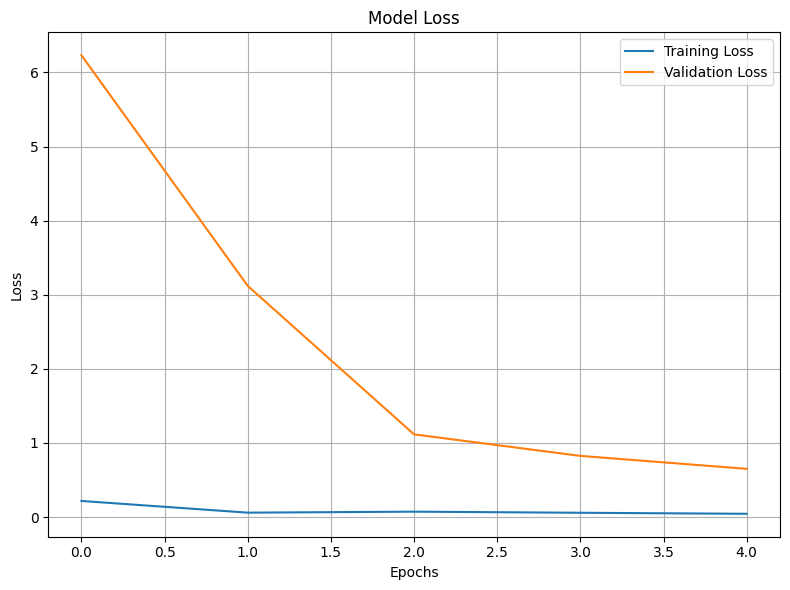

time: 234 ms (started: 2026-04-02 22:13:31 +05:30)


In [26]:
fig, axs = plt.subplots( figsize=(8, 6))

axs.plot(fit.history['loss'], label='Training Loss')
axs.plot(fit.history['val_loss'], label='Validation Loss')
axs.set_title('Model Loss')
axs.set_xlabel('Epochs')
axs.set_ylabel('Loss')
axs.legend()
axs.grid(True)

plt.tight_layout()
plt.show()